In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("adult.csv")
print(df.head())
df.replace("?", np.nan, inplace=True)
df.dropna(axis=1, how="all", inplace=True)
print(df.head())

   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

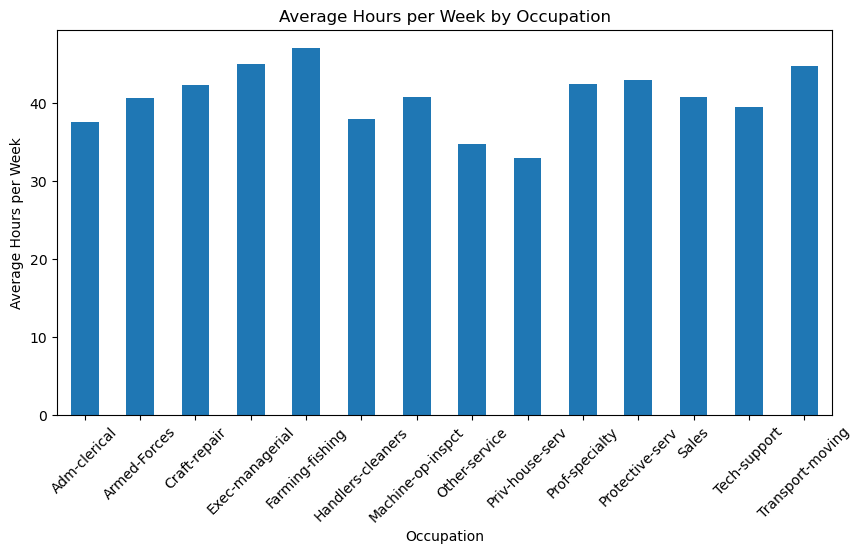

In [16]:
avg_hours = df.groupby("occupation")["hours.per.week"].mean()

avg_hours.plot(kind="bar", figsize=(10, 5))

plt.xlabel("Occupation")
plt.ylabel("Average Hours per Week")
plt.title("Average Hours per Week by Occupation")
plt.xticks(rotation=45)
plt.show()

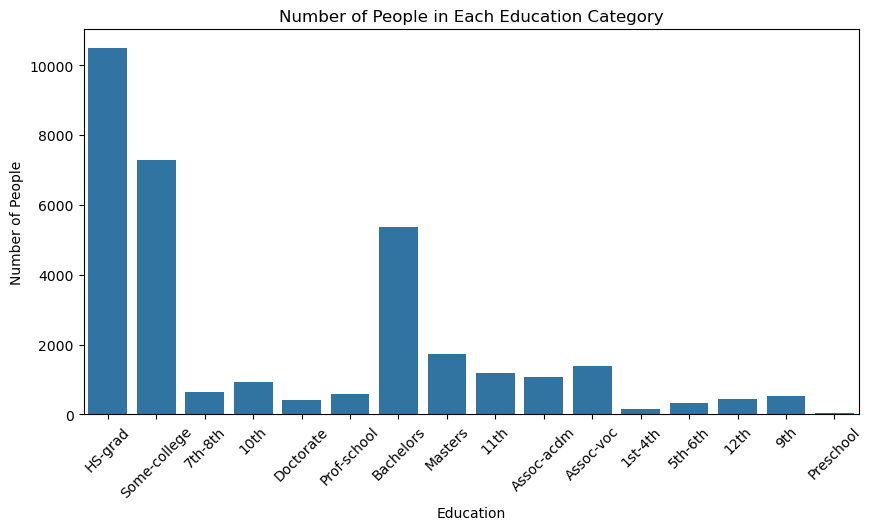

In [6]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="education")

plt.xlabel("Education")
plt.ylabel("Number of People")
plt.title("Number of People in Each Education Category")
plt.xticks(rotation=45)
plt.show()

# The most common category is the HS-grad category with the highest bar.

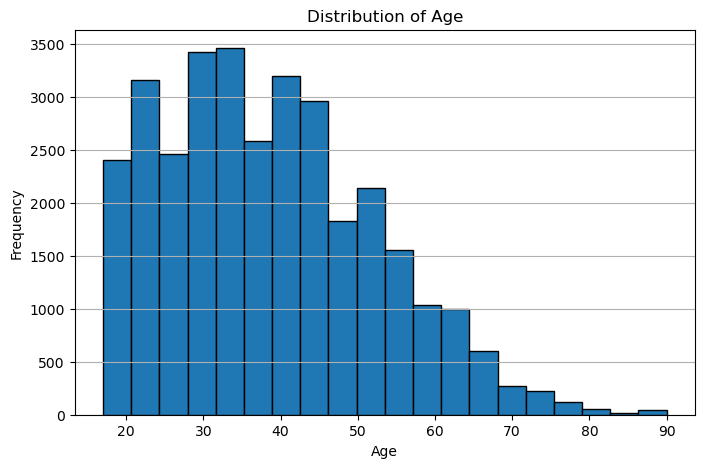

In [21]:
plt.figure(figsize=(8, 5))

n, bins, patches = plt.hist(
    df["age"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.grid(axis="y")

plt.show()
# The age distribution is slightly right-skewed because there are more values toward the lower ages and a tail toward older ages.

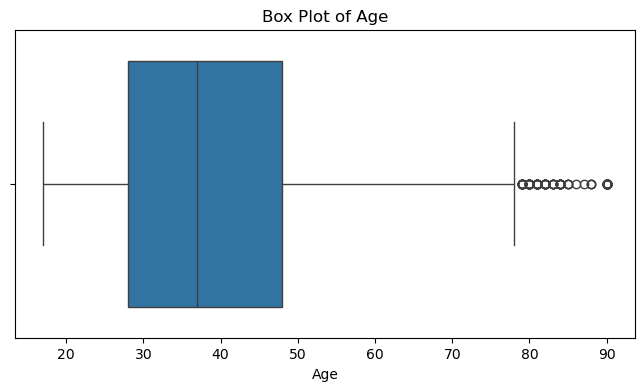

In [22]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["age"])

plt.xlabel("Age")
plt.title("Box Plot of Age")
plt.show()

# The points outside the whiskers are the possible outliers

In [23]:
# Task 5: Calculate outliers using IQR

Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["age"] < lower) | (df["age"] > upper)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outliers:", len(outliers))
#There are so many outliers so I cannot count

Q1: 28.0
Q3: 48.0
IQR: 20.0
Lower bound: -2.0
Upper bound: 78.0
Number of outliers: 143


In [25]:

df["zscore"] = stats.zscore(df["age"])

outliers_z = df[df["zscore"].abs() > 3]

print("Number of Z-score outliers:", len(outliers_z))


# A value is considered an outlier here when its absolute z-score is greater than 3.
# Z score is preferred when data is normally distributed but this data is skewed so it gives different answers

Number of Z-score outliers: 121


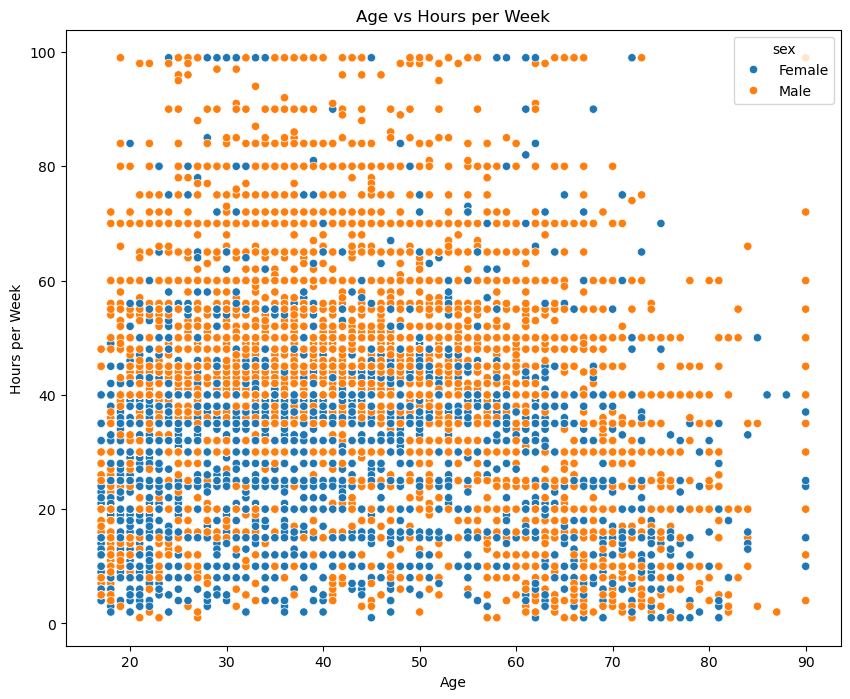

In [32]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x="age",
    y="hours.per.week",
    hue="sex"
)

plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.title("Age vs Hours per Week")
plt.show()
#people work hours more between age 20 to 60
#As age increases decrease in work is seen so it is negatively corelated as well 

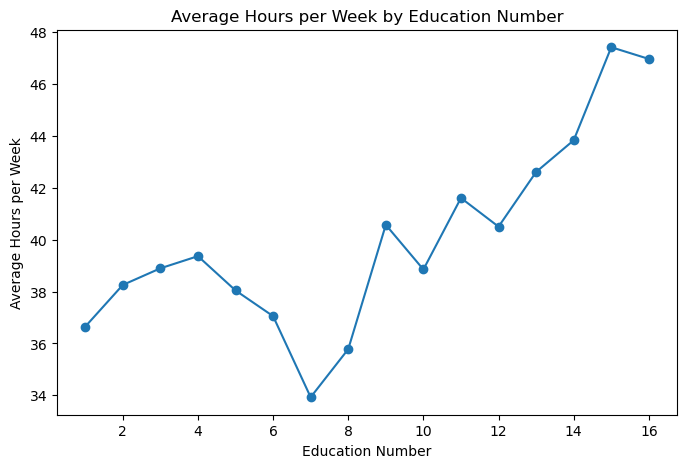

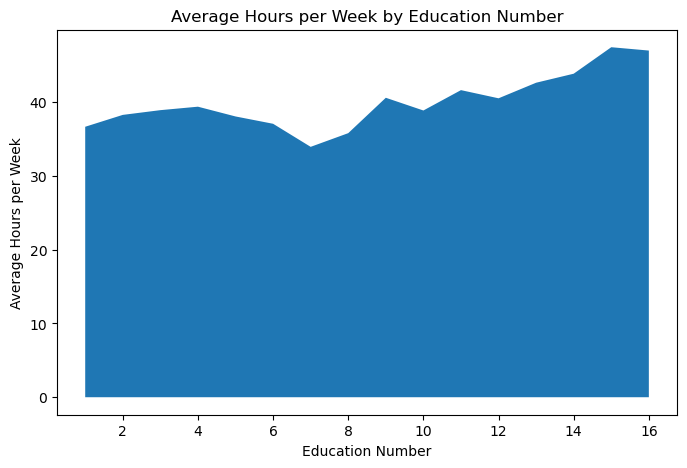

In [29]:

education_hours = df.groupby("education.num")["hours.per.week"].mean()

plt.figure(figsize=(8, 5))

plt.plot(education_hours.index, education_hours.values, marker="o")

plt.xlabel("Education Number")
plt.ylabel("Average Hours per Week")
plt.title("Average Hours per Week by Education Number")
plt.show()

plt.figure(figsize=(8, 5))

plt.fill_between(
    education_hours.index,
    education_hours.values
)

plt.xlabel("Education Number")
plt.ylabel("Average Hours per Week")
plt.title("Average Hours per Week by Education Number")
plt.show()


# The area chart makes the amount or magnitude look stronger because the space below the line is filled, while the line chart focuses more on the trend.

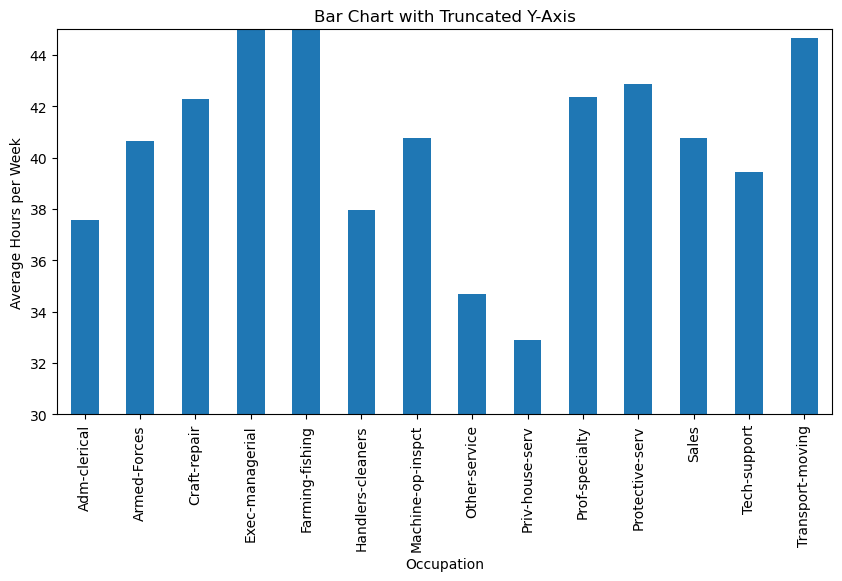

In [30]:
# Task 9: Bar chart with a truncated y-axis

plt.figure(figsize=(10, 5))

avg_hours.plot(kind="bar")

plt.xlabel("Occupation")
plt.ylabel("Average Hours per Week")
plt.title("Bar Chart with Truncated Y-Axis")

plt.ylim(30, 45)

plt.show()

# A truncated y-axis can make small differences between categories look much larger than they really are.
# The actual data has not changed, but the graph gives a more exaggerated impression of the differences.